In [248]:
import os
os.chdir(r'C:\Users\66959\Desktop\stats\data')
os.getcwd()

'C:\\Users\\66959\\Desktop\\stats\\data'

In [249]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [250]:
orig_df1 = pd.read_csv('worldbank_gender_2021.csv')
orig_df2 = pd.read_excel('countries_regions.xlsx')

In [251]:
orig_df = pd.merge(orig_df1, orig_df2, left_on='Country Name', right_on='CountryName')

In [252]:
orig_df.head()

,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,"Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",Gender Ratio Class,CountryName,Region,ThirdWorld
0,Afghanistan,2021,6.51,58.74,33.60,12.00,2099.0,125.67,5.20,114.32,...,12.79,NaN,NaN,NaN,NaN,NaN,1.0,Afghanistan,South Asia,Yes
1,Albania,2021,16.54,41.47,18.36,21.89,5144.7,114.68,NaN,104.92,...,15.96,NaN,NaN,NaN,NaN,NaN,1.0,Albania,Eastern Europe,No
2,Algeria,2021,NaN,17.35,11.23,3.16,1433.7,108.76,20.68,104.83,...,1.61,NaN,NaN,NaN,NaN,NaN,1.0,Algeria,Africa,No
3,American Samoa,2021,NaN,14.50,NaN,4.85,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,American Samoa,Australia and Oceanea,No
4,Andorra,2021,NaN,39.91,0.53,1.59,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Andorra,Western Europe,No


In [253]:
orig_df = orig_df.drop(columns=['CountryName', 'Country Name', 'Year'])

In [254]:
df = orig_df.copy()

# Train-test split

In [255]:
X = df.drop(columns=["Gender Ratio Class"])
y = df["Gender Ratio Class"]

In [256]:
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

In [257]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99, stratify=y)

# Data preprocessing 

## Handling missing values

In [258]:
print((X_train.isna().mean() * 100).to_string())

Agricultural irrigated land (% of total agricultural land)                                                                                      76.870748
Agricultural land (% of land area)                                                                                                               0.680272
Agriculture, forestry, and fishing, value added (% of GDP)                                                                                       7.482993
Arable land (% of land area)                                                                                                                     0.680272
Cereal yield (kg per hectare)                                                                                                                    7.482993
Crop production index (2014-2016 = 100)                                                                                                          2.040816
Fertilizer consumption (kilograms per hectare of arable land)               

In [259]:
print((y_train.isna().mean() * 100))

0.0


In [260]:
threshold = 0.4
missing_ratio = X_train.isna().mean()
drop_cols = missing_ratio[missing_ratio > threshold].index

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [261]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object','category']).columns

In [262]:
cat_cols

Index(['Region', 'ThirdWorld'], dtype='object')

In [263]:
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())

X_train[cat_cols] = X_train[cat_cols].fillna(X_train[cat_cols].mode())
X_test[cat_cols] = X_test[cat_cols].fillna(X_train[cat_cols].mode())

In [264]:
y_train = y_train.fillna(y_train.mode().iloc[0])
y_test = y_test.fillna(y_train.mode().iloc[0])

In [265]:
print((X_train.isna().mean() * 100).to_string())

Agricultural land (% of land area)                                                                 0.0
Agriculture, forestry, and fishing, value added (% of GDP)                                         0.0
Arable land (% of land area)                                                                       0.0
Cereal yield (kg per hectare)                                                                      0.0
Crop production index (2014-2016 = 100)                                                            0.0
Fertilizer consumption (kilograms per hectare of arable land)                                      0.0
Food production index (2014-2016 = 100)                                                            0.0
Forest area (% of land area)                                                                       0.0
Forest area (sq. km)                                                                               0.0
Land area (sq. km)                                                       

## Encoding

In [266]:
cat_cols

Index(['Region', 'ThirdWorld'], dtype='object')

In [267]:
X_train.shape

(147, 97)

In [268]:
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=True)
    return df

In [269]:
X_train = onehot_encoder_selected(X_train, cat_cols)
X_test = onehot_encoder_selected(X_test, cat_cols)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [270]:
X_train.shape

(147, 108)

In [271]:
X_test.shape

(37, 108)

## Scaling

In [272]:
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Feature selection

In [273]:
X_train.head()

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe,ThirdWorld_Yes
68,13.97,7.18,0.72,3120.4,102.15,103.48,103.74,43.06,1494.60,3471.0,...,False,False,False,False,False,False,False,False,False,False
26,28.64,6.56,6.97,4477.4,115.35,369.47,112.13,59.27,4953913.67,8358140.0,...,False,False,False,True,False,False,False,False,False,False
5,36.81,11.49,4.31,1000.1,116.22,5.61,117.50,52.98,660523.13,1246700.0,...,False,False,False,False,False,False,False,False,False,True
204,71.16,0.71,24.84,6966.8,90.10,240.94,100.53,13.22,31986.67,241930.0,...,False,False,True,False,False,False,False,False,False,False
210,64.93,6.32,6.95,2251.9,117.31,371.97,117.39,1.68,101.40,6025.0,...,True,False,False,False,False,False,False,False,False,False


## Low Variance Filtering

In [274]:
X_train.var().sort_values(ascending=False)

GNI, PPP (current international $)                                          6.922818e+24
GDP (current US$)                                                           2.542482e+24
Total reserves (includes gold, current US$)                                 1.076684e+23
Merchandise exports (current US$)                                           9.816581e+22
Merchandise imports (current US$)                                           7.417258e+22
                                                                                ...     
Price level ratio of PPP conversion factor (GDP) to market exchange rate    5.038356e-02
Region_East Asia                                                            4.566210e-02
Region_South Asia                                                           4.566210e-02
Region_Western Asia                                                         3.308173e-02
Region_Thailand                                                             6.802721e-03
Length: 108, dtype: f

In [275]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
selector.fit(X_train)

updated_vars = X_train.columns[selector.get_support()].tolist()
updated_vars

['Agricultural land (% of land area)',
 'Agriculture, forestry, and fishing, value added (% of GDP)',
 'Arable land (% of land area)',
 'Cereal yield (kg per hectare)',
 'Crop production index (2014-2016 = 100)',
 'Fertilizer consumption (kilograms per hectare of arable land)',
 'Food production index (2014-2016 = 100)',
 'Forest area (% of land area)',
 'Forest area (sq. km)',
 'Land area (sq. km)',
 'Livestock production index (2014-2016 = 100)',
 'Permanent cropland (% of land area)',
 'Rural population',
 'Rural population (% of total population)',
 'Surface area (sq. km)',
 'Access to electricity (% of population)',
 'Annual freshwater withdrawals, total (% of internal resources)',
 'Mortality rate, under-5 (per 1,000 live births)',
 'Population growth (annual %)',
 'Population in urban agglomerations of more than 1 million (% of total population)',
 'Population, total',
 'Primary completion rate, total (% of relevant age group)',
 'Renewable energy consumption (% of total final e

In [276]:
len(updated_vars)

108

In [277]:
X_train = X_train[updated_vars]
X_test = X_test[updated_vars]
X_train.head()

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe,ThirdWorld_Yes
68,13.97,7.18,0.72,3120.4,102.15,103.48,103.74,43.06,1494.60,3471.0,...,False,False,False,False,False,False,False,False,False,False
26,28.64,6.56,6.97,4477.4,115.35,369.47,112.13,59.27,4953913.67,8358140.0,...,False,False,False,True,False,False,False,False,False,False
5,36.81,11.49,4.31,1000.1,116.22,5.61,117.50,52.98,660523.13,1246700.0,...,False,False,False,False,False,False,False,False,False,True
204,71.16,0.71,24.84,6966.8,90.10,240.94,100.53,13.22,31986.67,241930.0,...,False,False,True,False,False,False,False,False,False,False
210,64.93,6.32,6.95,2251.9,117.31,371.97,117.39,1.68,101.40,6025.0,...,True,False,False,False,False,False,False,False,False,False


## High Correlation Filtering

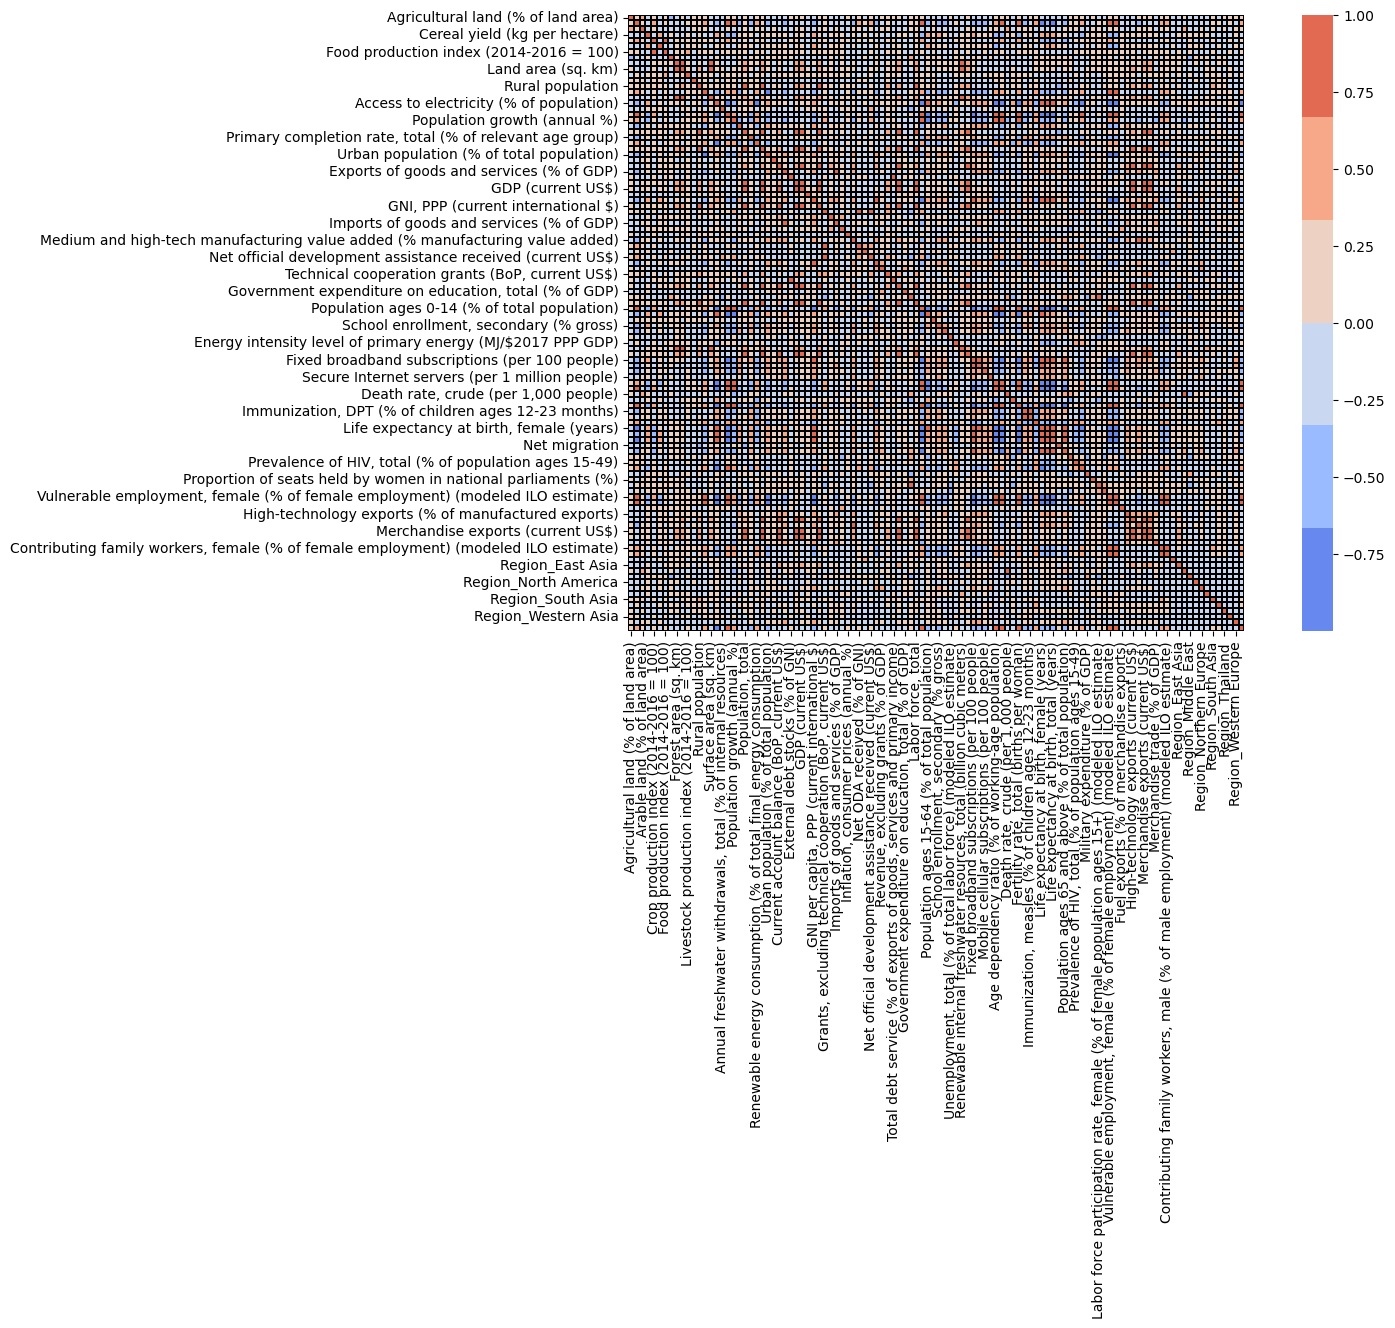

In [278]:
plt.figure(figsize=(15,8))
sns.heatmap(X_train.corr(),
            square=True,
            linewidths=0.25,    
            linecolor=(0,0,0),
            cmap=sns.color_palette("coolwarm"),
            annot=False)
plt.show()

In [279]:
def drop_high_corr_cols_with_target(X, y, threshold=0.8):
    corr = X.corr().abs()
    target_corr = X.apply(lambda col: col.corr(y)).abs()

    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    drop_cols = set()

    for col in upper.columns:
        if col in drop_cols:
            continue
        high_corr = upper[col][upper[col] > threshold].index
        for other in high_corr:
            if other in drop_cols:
                continue
            if target_corr[col] < target_corr[other]:
                drop_cols.add(col)
                break
            else:
                drop_cols.add(other)


    return list(drop_cols)

In [280]:
drop_cols = drop_high_corr_cols(X_train, threshold=0.9)

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [281]:
X_train.shape

(147, 89)

In [282]:
X_test.shape

(37, 89)

# Modeling 

In [283]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict

{np.float64(1.0): np.float64(1.1307692307692307),
 np.float64(2.0): np.float64(0.6391304347826087),
 np.float64(3.0): np.float64(1.176),
 np.float64(4.0): np.float64(1.96),
 np.float64(5.0): np.float64(0.84)}

In [284]:
sample_weight = y_train.map(class_weight_dict)

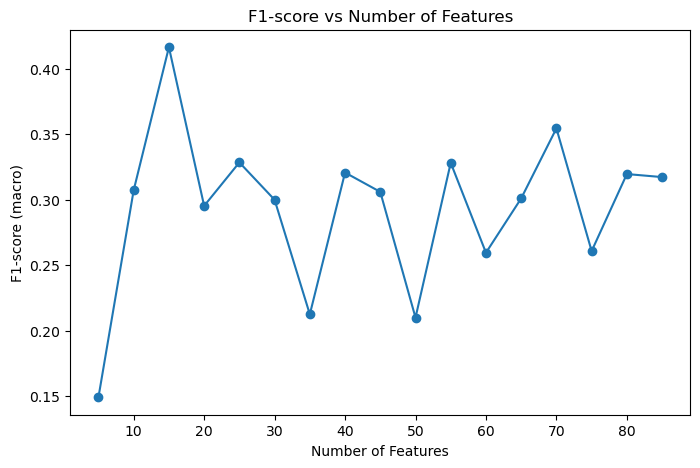

In [285]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

base_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,     
    max_depth=5, 
    gamma=0.1, 
    min_child_weight=1,     
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=0
)

base_model.fit(X_train, y_train_enc, sample_weight=sample_weight)

importances = pd.Series(
    base_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

results = []

for n_features in range(5, len(importances) + 1, 5):
    selected_features = importances.head(n_features).index

    X_tr = X_train[selected_features]
    X_te = X_test[selected_features]

    model = xgb.XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,     
        max_depth=5,
        gamma=0.1, 
        min_child_weight=1,     
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=0
    )

    model.fit(X_tr, y_train_enc, sample_weight=sample_weight)
    y_pred = model.predict(X_te)

    f1 = f1_score(y_test_enc, y_pred, average="macro")
    results.append((n_features, f1))

results_df = pd.DataFrame(results, columns=["n_features", "f1_macro"])

best_row = results_df.loc[results_df["f1_macro"].idxmax()]
best_n_features = int(best_row["n_features"])
best_f1 = best_row["f1_macro"]

best_features = importances.head(best_n_features).index

X_train = X_train[best_features]
X_test  = X_test[best_features]

plt.figure(figsize=(8, 5))
plt.plot(results_df["n_features"], results_df["f1_macro"], marker="o")
plt.xlabel("Number of Features")
plt.ylabel("F1-score (macro)")
plt.title("F1-score vs Number of Features")
plt.show()

In [286]:
# Function to compute performance classification metrics
def evaluate_performance(y_true, y_pred, average_val='macro'):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average_val)
    recall = recall_score(y_true, y_pred, average=average_val)
    f1 = f1_score(y_true, y_pred, average=average_val)

    from sklearn.metrics import confusion_matrix
    confusion = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, confusion

In [287]:
X_train.shape

(147, 15)

In [288]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,     
    max_depth=5,            
    min_child_weight=1,
    gamma=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=0
)

model.fit(X_train, y_train, sample_weight=sample_weight)
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

[[2 5 0 0 0]
 [4 7 0 0 0]
 [1 1 1 1 2]
 [0 1 0 3 0]
 [2 2 0 2 3]]
0.43243243243243246 0.5519444444444445 0.4344155844155845 0.4165608465608465


# Performance evaluation

In [289]:
print(confusion)
print(acc, precision, recall, f1)

[[2 5 0 0 0]
 [4 7 0 0 0]
 [1 1 1 1 2]
 [0 1 0 3 0]
 [2 2 0 2 3]]
0.43243243243243246 0.5519444444444445 0.4344155844155845 0.4165608465608465


In [290]:
# Get summary of classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.22      0.29      0.25         7
           1       0.44      0.64      0.52        11
           2       1.00      0.17      0.29         6
           3       0.50      0.75      0.60         4
           4       0.60      0.33      0.43         9

    accuracy                           0.43        37
   macro avg       0.55      0.43      0.42        37
weighted avg       0.53      0.43      0.42        37



In [291]:
y_score = model.predict_proba(X_test)

In [292]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

roc_auc_macro = roc_auc_score(
    y_test,
    y_score,
    multi_class="ovr",
    average="macro"
)

roc_auc_micro = roc_auc_score(
    y_test,
    y_score,
    multi_class="ovr",
    average="micro"
)

roc_auc_per_class = roc_auc_score(
    y_test,
    y_score,
    multi_class="ovr",
    average=None
)

print(f"ROC AUC Macro: {roc_auc_macro:.4f}")
print(f"ROC AUC Micro: {roc_auc_micro:.4f}")

print("===============================")

for cls, auc_val in zip(model.classes_, roc_auc_per_class):
    print(f"ROC AUC Class {cls}: {auc_val:.4f}")

ROC AUC Macro: 0.6938
ROC AUC Micro: 0.7082
ROC AUC Class 0: 0.6476
ROC AUC Class 1: 0.6748
ROC AUC Class 2: 0.6344
ROC AUC Class 3: 0.8333
ROC AUC Class 4: 0.6786


In [293]:
from sklearn.preprocessing import label_binarize

classes = model.classes_
num_classes = len(classes)

y_score = model.predict_proba(X_test)
y_bin = label_binarize(y_test, classes=classes)

In [294]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(
        y_bin[:, i],
        y_score[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

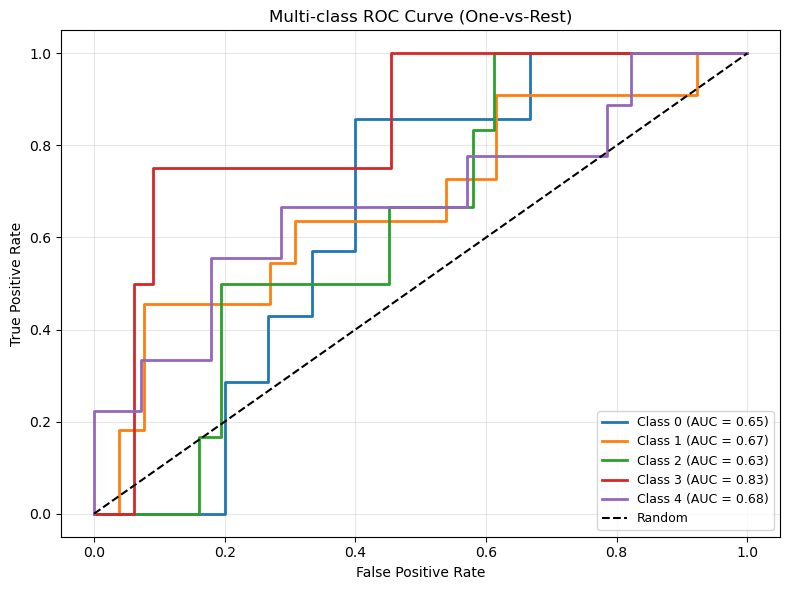

In [295]:
from itertools import cycle

plt.figure(figsize=(8, 6))
colors = cycle(plt.cm.tab10.colors)

for i, color in zip(range(num_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [296]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision = {}
recall = {}
avg_precision = {}

for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_bin[:, i],
        y_score[:, i]
    )
    avg_precision[i] = average_precision_score(
        y_bin[:, i],
        y_score[:, i]
    )

In [297]:
ap_macro = average_precision_score(
    y_bin,
    y_score,
    average="macro"
)

ap_micro = average_precision_score(
    y_bin,
    y_score,
    average="micro"
)

print(f"Average Precision Macro: {ap_macro:.4f}")
print(f"Average Precision Micro: {ap_micro:.4f}")

print("===============================")
for cls, ap in zip(classes, avg_precision.values()):
    print(f"AP Class {cls}: {ap:.4f}")

Average Precision Macro: 0.3846
Average Precision Micro: 0.3635
AP Class 0: 0.2626
AP Class 1: 0.4999
AP Class 2: 0.2383
AP Class 3: 0.3860
AP Class 4: 0.5361


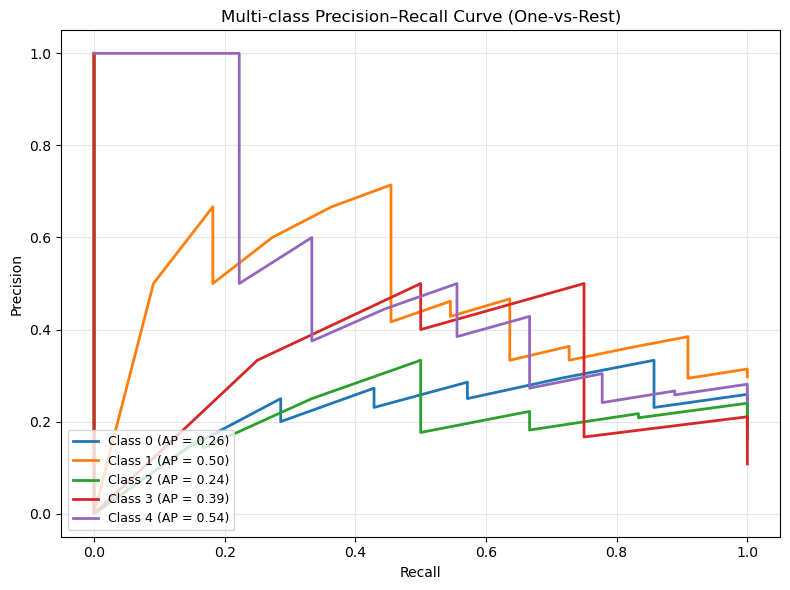

In [298]:
plt.figure(figsize=(8, 6))
colors = cycle(plt.cm.tab10.colors)

for i, color in zip(range(num_classes), colors):
    plt.plot(
        recall[i],
        precision[i],
        lw=2,
        color=color,
        label=f'Class {classes[i]} (AP = {avg_precision[i]:.2f})'
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multi-class Precision–Recall Curve (One-vs-Rest)')
plt.legend(loc='lower left', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Result interpretation

In [299]:
def get_permutation_importance(model, X, X_true, y_true):
    from sklearn.inspection import permutation_importance
    result = permutation_importance(model, X_test, y_test, n_repeats=10)
    
    perm_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)
    
    return perm_df

    # Higher value = more important feature, relatively compared to other features
    # Near-zero value = unimportant feature, relatively compared to other features
    # Negative value = noisy feature

In [300]:
get_permutation_importance(model, X_train, X_test, y_test)

,feature,importance_mean,importance_std
12,Food production index (2014-2016 = 100),0.108108,0.045225
2,Forest area (sq. km),0.081081,0.034187
1,"Vulnerable employment, female (% of female emp...",0.081081,0.029607
7,"Life expectancy at birth, female (years)",0.067568,0.018130
14,Price level ratio of PPP conversion factor (GD...,0.062162,0.027162
3,Land area (sq. km),0.059459,0.026481
10,"Adjusted net savings, including particulate em...",0.051351,0.058531
9,External debt stocks (% of GNI),0.043243,0.021622
5,Secure Internet servers (per 1 million people),0.037838,0.056949
11,Region_Eastern Europe,0.037838,0.013240


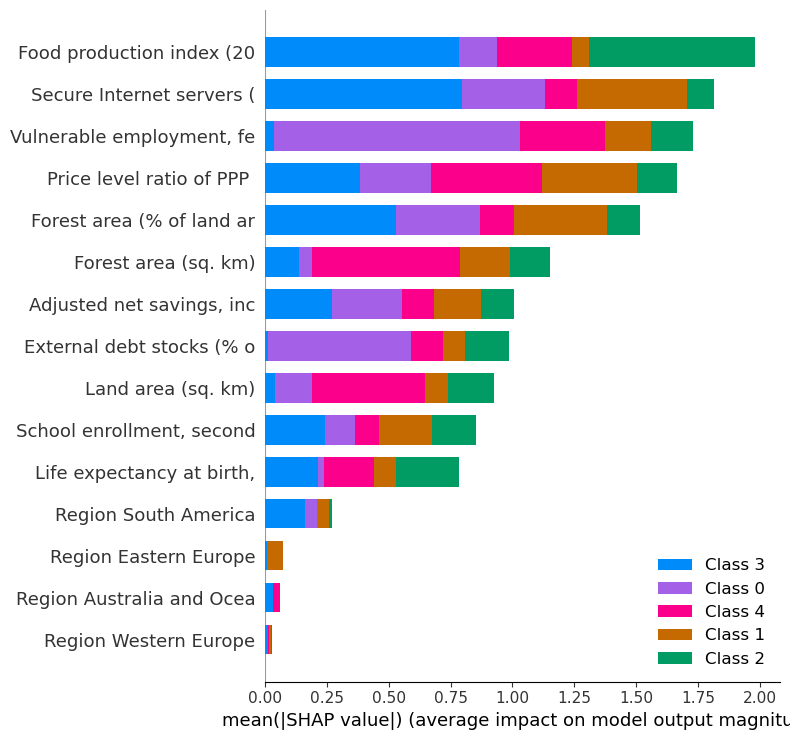

In [305]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

X_test_short = X_test.copy()
X_test_short.columns = [c.replace('_', ' ')[:25] for c in X_test.columns]

shap.summary_plot(
    shap_values,
    X_test_short,
    plot_type="bar",
)

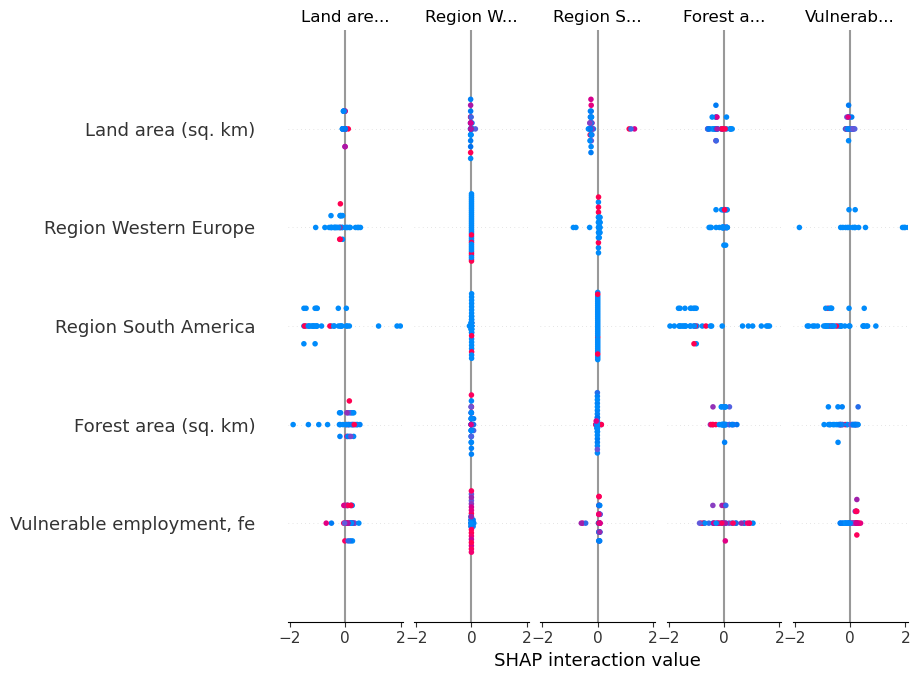

In [306]:
shap.summary_plot(
    shap_values,
    X_test_short,
)

In [307]:
def permutation_importance_per_class(model, X, y, target_class, n_repeats=10):
    from sklearn.inspection import permutation_importance
    y_binary = (y == target_class).astype(int)

    def auc_scorer(estimator, X_val, y_val):
        y_prob = estimator.predict_proba(X_val)[:, target_class]
        return roc_auc_score(y_val, y_prob)

    result = permutation_importance(
        model,
        X,
        y_binary,
        scoring=auc_scorer,
        n_repeats=n_repeats,
        random_state=0
    )

    return pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)


In [308]:
for cls in model.classes_:
    print(f"\n===== Permutation Importance : Class {cls} =====")
    pi_df = permutation_importance_per_class(
        model, X_test, y_test, target_class=cls
    )
    display(pi_df.head(10))


===== Permutation Importance : Class 0 =====


,feature,importance_mean,importance_std
1,"Vulnerable employment, female (% of female emp...",0.087143,0.085078
5,Secure Internet servers (per 1 million people),0.068095,0.100724
9,External debt stocks (% of GNI),0.020000,0.036996
0,Region_Western Europe,0.000000,0.000000
8,Region_Australia and Oceanea,0.000000,0.000000
4,Region_South America,-0.001905,0.003810
3,Land area (sq. km),-0.014286,0.022131
12,Food production index (2014-2016 = 100),-0.015238,0.016330
11,Region_Eastern Europe,-0.017143,0.005303
2,Forest area (sq. km),-0.019524,0.020806



===== Permutation Importance : Class 1 =====


,feature,importance_mean,importance_std
14,Price level ratio of PPP conversion factor (GD...,0.074825,0.043593
5,Secure Internet servers (per 1 million people),0.069231,0.042387
9,External debt stocks (% of GNI),0.038462,0.019717
1,"Vulnerable employment, female (% of female emp...",0.036014,0.027176
7,"Life expectancy at birth, female (years)",0.022727,0.017570
3,Land area (sq. km),0.011538,0.027799
8,Region_Australia and Oceanea,0.000350,0.001049
4,Region_South America,0.000350,0.005055
0,Region_Western Europe,-0.000350,0.001049
10,"Adjusted net savings, including particulate em...",-0.003497,0.037756



===== Permutation Importance : Class 2 =====


,feature,importance_mean,importance_std
13,Forest area (% of land area),0.088710,0.047131
2,Forest area (sq. km),0.083871,0.057313
5,Secure Internet servers (per 1 million people),0.055376,0.037561
14,Price level ratio of PPP conversion factor (GD...,0.045161,0.043558
9,External debt stocks (% of GNI),0.032258,0.037326
10,"Adjusted net savings, including particulate em...",0.029570,0.019273
6,"School enrollment, secondary (% gross)",0.015591,0.033528
4,Region_South America,0.013441,0.008752
1,"Vulnerable employment, female (% of female emp...",0.011290,0.045775
11,Region_Eastern Europe,0.007527,0.004301



===== Permutation Importance : Class 3 =====


,feature,importance_mean,importance_std
13,Forest area (% of land area),0.151515,0.054839
12,Food production index (2014-2016 = 100),0.103030,0.046725
14,Price level ratio of PPP conversion factor (GD...,0.031061,0.025229
10,"Adjusted net savings, including particulate em...",0.022727,0.036015
7,"Life expectancy at birth, female (years)",0.019697,0.027357
4,Region_South America,0.006061,0.007423
9,External debt stocks (% of GNI),0.004545,0.014051
5,Secure Internet servers (per 1 million people),0.004545,0.013209
11,Region_Eastern Europe,0.002273,0.008333
0,Region_Western Europe,0.000000,0.000000



===== Permutation Importance : Class 4 =====


,feature,importance_mean,importance_std
3,Land area (sq. km),0.080556,0.029055
2,Forest area (sq. km),0.045238,0.039252
14,Price level ratio of PPP conversion factor (GD...,0.039286,0.052867
9,External debt stocks (% of GNI),0.007540,0.026230
11,Region_Eastern Europe,0.005556,0.003637
10,"Adjusted net savings, including particulate em...",0.003968,0.059550
0,Region_Western Europe,0.000397,0.001190
12,Food production index (2014-2016 = 100),-0.001190,0.043254
4,Region_South America,-0.002778,0.009399
1,"Vulnerable employment, female (% of female emp...",-0.003571,0.041256


In [236]:
import shap

explainer = shap.TreeExplainer(model)
shap_exp = explainer(X_test)


===== SHAP Global Importance : Class 0 =====


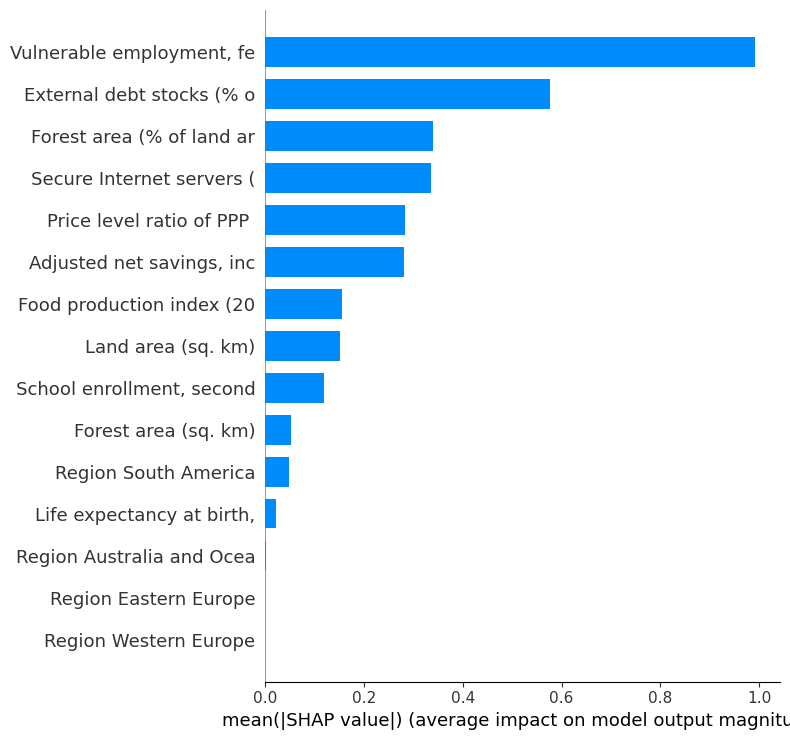


===== SHAP Global Importance : Class 1 =====


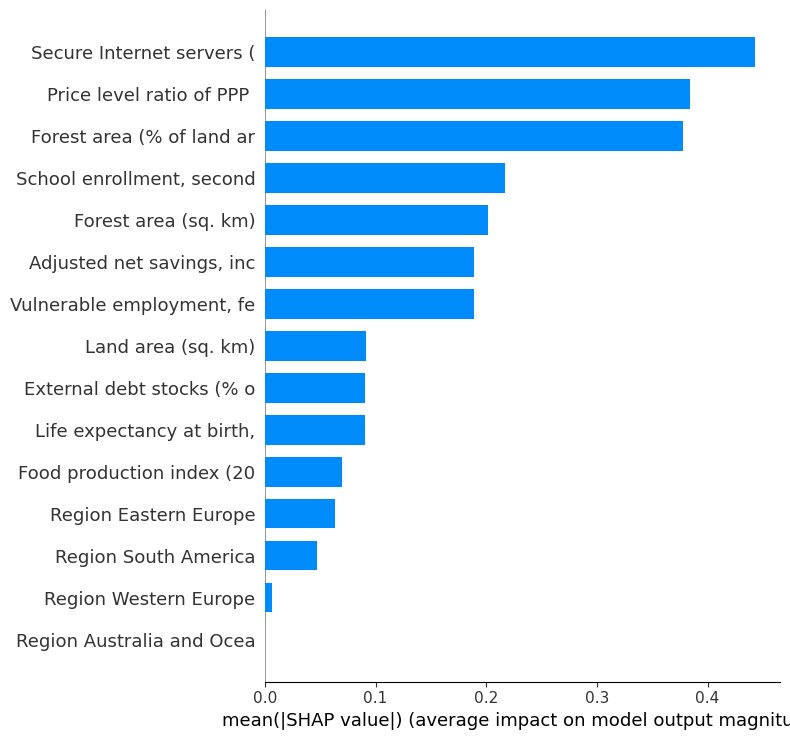


===== SHAP Global Importance : Class 2 =====


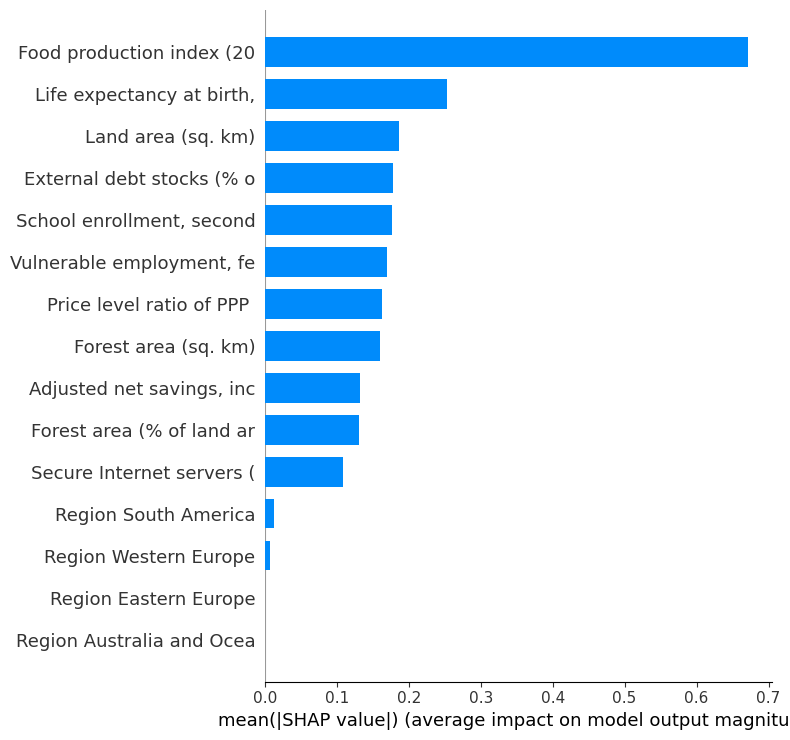


===== SHAP Global Importance : Class 3 =====


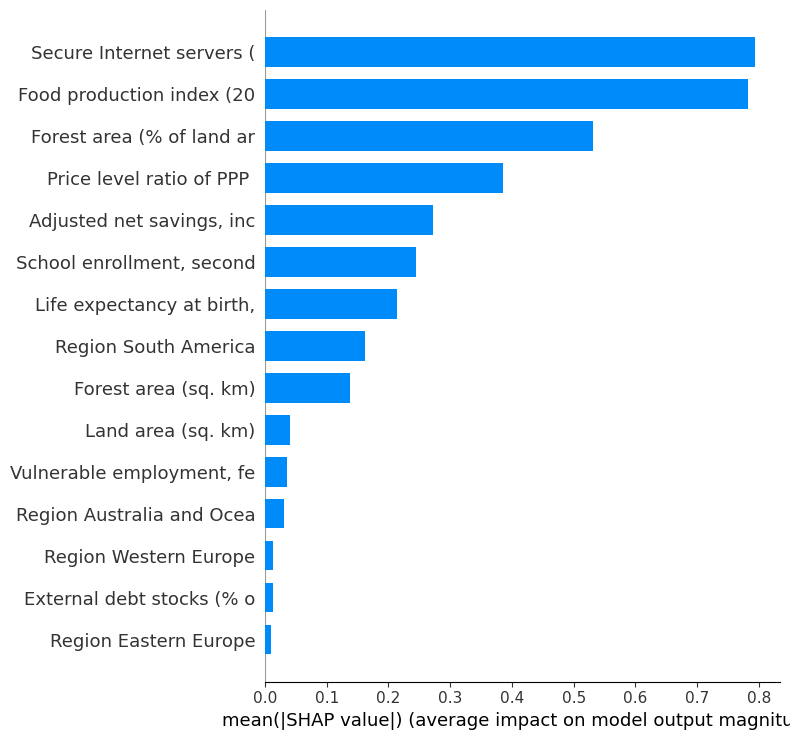


===== SHAP Global Importance : Class 4 =====


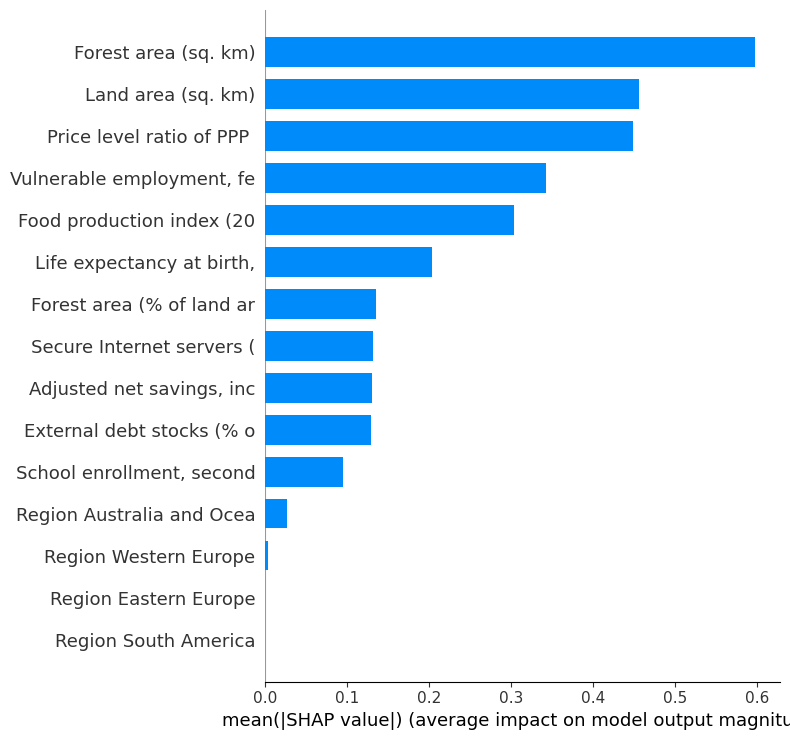

In [309]:
for i, cls in enumerate(model.classes_):
    print(f"\n===== SHAP Global Importance : Class {cls} =====")

    shap.summary_plot(
        shap_exp.values[:, :, i],   # ← เลือกคลาส
        X_test_short,
        plot_type="bar",
        show=True
    )

In [310]:
df = df.rename(columns={
    "Gender Ratio Class": "GenderRatioClass"
})

In [311]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

model = ols(
    'GenderRatioClass ~ C(Region)',
    data=df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

               sum_sq     df         F    PR(>F)
C(Region)   78.539179   12.0  3.680682  0.000062
Residual   304.069517  171.0       NaN       NaN


In [312]:
df.groupby('Region')['GenderRatioClass'].mean()

Region
Africa                   2.596154
Australia and Oceanea    3.727273
East Asia                2.857143
Eastern Europe           2.187500
Middle East              3.812500
North America            3.000000
Northern Europe          3.700000
South America            3.000000
South Asia               1.375000
Southeast Asia           2.222222
Thailand                 1.000000
Western Asia             3.875000
Western Europe           3.461538
Name: GenderRatioClass, dtype: float64

In [313]:
contingency_table = pd.crosstab(df['GenderRatioClass'], df['Region'])
print(contingency_table)

Region            Africa  Australia and Oceanea  East Asia  Eastern Europe  \
GenderRatioClass                                                             
1.0                   17                      1          1               2   
2.0                   12                      2          3              11   
3.0                    9                      0          1               2   
4.0                    3                      4          0               0   
5.0                   11                      4          2               1   

Region            Middle East  North America  Northern Europe  South America  \
GenderRatioClass                                                               
1.0                         2              2                0              0   
2.0                         2              9                2              4   
3.0                         2              3                2              4   
4.0                         1              1         

In [314]:
# Chi-square test
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 98.37309709634914
p-value: 2.5094422769798523e-05
